# Project objective:


## - analyze Arizona coffee shops

## - identify market patterns and possible expansion opportunities

# Connect to SQLite

In [6]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("../coffee_analysis.db")

# Inspect the tables

In [7]:
# Show table names
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,business
1,reviews
2,tips
3,checkins
4,users


In [8]:
# Preview each table
pd.read_sql_query("SELECT * FROM business LIMIT 5;", conn)
pd.read_sql_query("SELECT * FROM reviews LIMIT 5;", conn)
pd.read_sql_query("SELECT * FROM tips LIMIT 5;", conn)
pd.read_sql_query("SELECT * FROM checkins LIMIT 5;", conn)
pd.read_sql_query("SELECT * FROM users LIMIT 5;", conn)

,user_id,review_count,yelping_since,useful,funny,cool,fans,average_stars
0,x7YtLnBW2dUnrrpwaofVQQ,37,2010-05-06 00:40:56,56,29,29,9,3.84
1,QJI9OSEn6ujRCtrX06vs1w,1982,2007-03-19 18:15:32,14004,6466,9879,316,3.61
2,KXZ8A8h7Q9ZJRU5TM9asjw,102,2010-03-20 17:40:40,150,42,30,7,3.54
3,2l0O1EI1m0yWjFo2zSt71w,2837,2005-07-02 01:59:55,19237,9542,15235,492,3.92
4,uVtkixXCP7LXRpC1EedGpA,77,2011-03-08 03:00:03,248,72,84,14,3.91


In [9]:
# Inspect the tables
pd.read_sql_query("PRAGMA table_info(business);", conn)
pd.read_sql_query("PRAGMA table_info(reviews);", conn)
pd.read_sql_query("PRAGMA table_info(tips);", conn)
pd.read_sql_query("PRAGMA table_info(checkins);", conn)
pd.read_sql_query("PRAGMA table_info(users);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,user_id,TEXT,0,None,0
1,1,review_count,INTEGER,0,None,0
2,2,yelping_since,TEXT,0,None,0
3,3,useful,INTEGER,0,None,0
4,4,funny,INTEGER,0,None,0
5,5,cool,INTEGER,0,None,0
6,6,fans,INTEGER,0,None,0
7,7,average_stars,REAL,0,None,0


# ERD
```mermaid
erDiagram
    BUSINESS ||--o{ REVIEWS : has
    BUSINESS ||--o{ TIPS : has
    BUSINESS ||--o{ CHECKINS : has
    USERS ||--o{ REVIEWS : writes
    USERS ||--o{ TIPS : writes

    BUSINESS {
        string business_id PK
        string name
        string city
        string state
        float latitude
        float longitude
        float stars
        int review_count
        string categories
        int is_open
    }

    REVIEWS {
        string review_id PK
        string user_id FK
        string business_id FK
        int stars
        int useful
        int funny
        int cool
        string text
        datetime date
        int review_length
    }

    TIPS {
        string user_id FK
        string business_id FK
        string text
        datetime date
        int compliment_count
        int tip_length
    }

    CHECKINS {
        string business_id FK
        string date
        string checkin_dates
        int total_checkins
    }

    USERS {
        string user_id PK
        int review_count
        datetime yelping_since
        int useful
        int funny
        int cool
        int fans
        float average_stars
    }
```

# Business questions

## Top cities by number of coffee shops

In [32]:
query = """
SELECT city, COUNT(*) AS total_coffee_shops
FROM business
GROUP BY city
ORDER BY total_coffee_shops DESC
LIMIT 10;
"""
top_cities = pd.read_sql_query(query, conn)
top_cities

,city,total_coffee_shops
0,Tucson,522
1,Oro Valley,18
2,Marana,12
3,Sahuarita,6
4,Vail,5
5,South Tucson,1
6,Mount Lemmon,1
7,Maran,1
8,Green Valley,1
9,Corona de Tucson,1


## Top businesses by review count

In [7]:
query = """
SELECT name, city, stars, review_count
FROM business
ORDER BY review_count DESC
LIMIT 10;
"""
top_businesses = pd.read_sql_query(query, conn)
top_businesses

,name,city,stars,review_count
0,Baja Cafe,Tucson,4.5,1074
1,Serial Grillers,Tucson,4.5,986
2,Cup Cafe,Tucson,4.0,862
3,Blue Willow Restaurant & Gift Shop,Tucson,4.0,625
4,Silver Saddle Steakhouse,Tucson,4.0,604
5,The Oink Cafe - Tucson,Tucson,3.5,597
6,Charro Steak & Del Rey,Tucson,4.0,589
7,Nook,Tucson,4.0,547
8,Yard House,Tucson,3.5,506
9,BK Tacos,Tucson,4.0,492


## City summary

In [8]:
query = """
SELECT city,
       COUNT(*) AS total_shops,
       ROUND(AVG(stars), 2) AS avg_rating,
       ROUND(AVG(review_count), 2) AS avg_reviews
FROM business
GROUP BY city
HAVING COUNT(*) >= 3
ORDER BY total_shops DESC;
"""
city_summary = pd.read_sql_query(query, conn)
city_summary

,city,total_shops,avg_rating,avg_reviews
0,Tucson,522,3.60,89.46
1,Oro Valley,18,3.72,64.22
2,Marana,12,2.92,48.08
3,Sahuarita,6,2.92,32.00
4,Vail,5,3.80,27.40


### Average rating by city

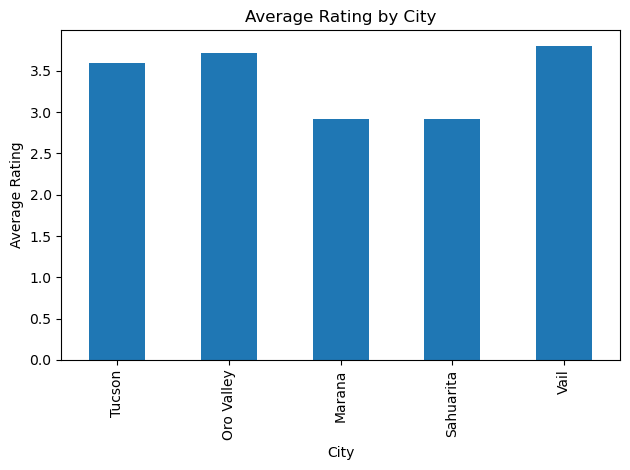

In [14]:
city_summary.head(10).plot(kind="bar", x="city", y="avg_rating", legend=False)
plt.title("Average Rating by City")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

### Top cities chart

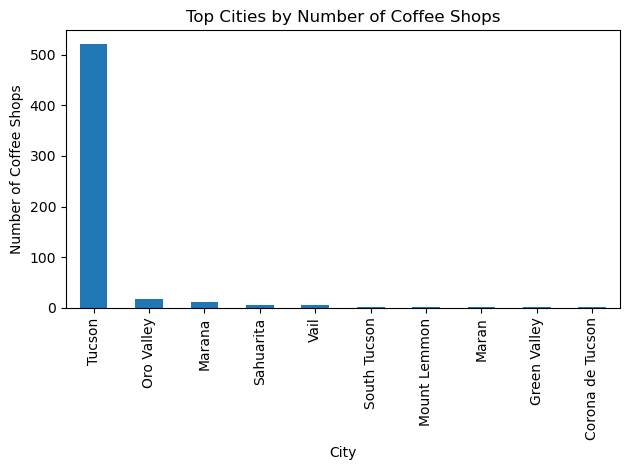

In [11]:
top_cities.plot(kind="bar", x="city", y="total_coffee_shops", legend=False)
plt.title("Top Cities by Number of Coffee Shops")
plt.xlabel("City")
plt.ylabel("Number of Coffee Shops")
plt.tight_layout()
plt.show()

## Business engagement

In [9]:
query = """
SELECT b.name,
       b.city,
       b.stars,
       b.review_count,
       COALESCE(c.total_checkins, 0) AS total_checkins
FROM business b
LEFT JOIN checkins c
  ON b.business_id = c.business_id
ORDER BY total_checkins DESC
LIMIT 10;
"""
top_checkins = pd.read_sql_query(query, conn)
top_checkins

,name,city,stars,review_count,total_checkins
0,Cup Cafe,Tucson,4.0,862,2282
1,Chatime - Bubble Tea Cafe,Tucson,3.5,182,1956
2,Sunny Daze Cafe,Tucson,4.5,398,1930
3,Cartel Roasting,Tucson,4.0,379,1648
4,Starbucks,Tucson,3.0,74,1645
5,Caffe Luce,Tucson,4.5,321,1439
6,Beyond Bread,Tucson,4.0,410,1421
7,Blue Willow Restaurant & Gift Shop,Tucson,4.0,625,1354
8,Beyond Bread,Tucson,4.5,439,1341
9,Baja Cafe,Tucson,4.5,1074,1340


### Review count vs rating

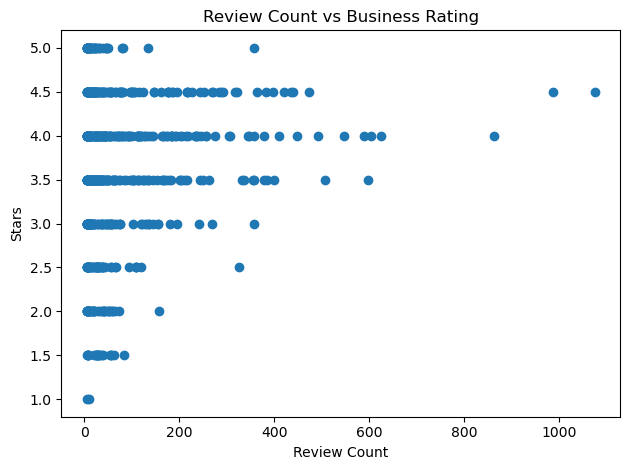

In [12]:
business_df = pd.read_sql_query("SELECT review_count, stars FROM business;", conn)

plt.scatter(business_df["review_count"], business_df["stars"])
plt.title("Review Count vs Business Rating")
plt.xlabel("Review Count")
plt.ylabel("Stars")
plt.tight_layout()
plt.show()

## Average review length by business

In [10]:
query = """
SELECT b.name,
       b.city,
       ROUND(AVG(r.review_length), 2) AS avg_review_length,
       COUNT(r.review_id) AS total_reviews
FROM reviews r
JOIN business b
  ON r.business_id = b.business_id
GROUP BY b.business_id, b.name, b.city
HAVING COUNT(r.review_id) >= 10
ORDER BY avg_review_length DESC
LIMIT 10;
"""
review_length_summary = pd.read_sql_query(query, conn)
review_length_summary

,name,city,avg_review_length,total_reviews
0,Teavana,Tucson,1159.86,14
1,Lohse Family Branch YMCA,Tucson,1147.35,23
2,City of Tucson,Tucson,1076.71,55
3,Cactus Rose,Tucson,912.59,22
4,Glass Onion Cafe,Tucson,884.88,16
5,"El Conquistador Tucson, A Hilton Resort",Tucson,880.18,279
6,Breakers Water Park,Maran,867.22,60
7,McMahon's Prime Steakhouse,Tucson,851.72,106
8,Five Palms Steak & Seafood,Tucson,832.37,142
9,Classic Spaghetti Western Steakhouse,Tucson,830.95,86
